# 03 — Churn Prediction Model

**SubscribeIQ — Subscription Intelligence & Retention Engine**

Goal: estimate each customer's probability of churning and, more importantly, understand
**which factors drive churn**, well enough to act on.

Design decisions (agreed before modelling):

| Decision | Choice | Reason |
|---|---|---|
| Features | All categorical columns (one-hot), tenure, monthly & total charges, `num_services`, R/F/M scores | `segment_name` and `estimated_ltv` excluded: both are derived from features already included |
| Imbalance (26.5% churn) | `class_weight="balanced"` (sample weights for GradientBoosting) | Makes missed churners count as much as false alarms during training |
| Split & tuning | Stratified 80/20; small grid search with 5-fold CV on the training set only | Test set is untouched until the final comparison |
| Model selection | Test ROC-AUC, recall as tie-breaker | Ranking quality first; missed churners are the costliest error |
| Probabilities in the DB | **Out-of-fold** (5-fold) predictions | Every customer is scored by a model that never saw them |
| Saved model | Best model refit on all data, preprocessing included (one Pipeline) | Reused by the dashboard what-if simulator and Phase 8 SHAP |

All logic lives in `src/churn_model.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sqlalchemy import text

sys.path.insert(0, str(Path.cwd().parent))
from src.db_connection import get_engine
from src import churn_model as cm

engine = get_engine()
pd.set_option("display.width", 160)

SURFACE, INK, INK_2, GRID, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#c9c8c3"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.titlelocation": "left", "font.size": 10, "figure.dpi": 110,
})

## 1. Train, tune and compare the three models

In [2]:
results = cm.run_pipeline(engine)   # trains, compares, writes OOF probabilities, saves the model
df, X_train, X_test, y_train, y_test = (results[k] for k in ["df", "X_train", "X_test", "y_train", "y_test"])
searches, comparison, best_name = results["searches"], results["comparison"], results["best_name"]

print(f"Features: {len(cm.FEATURES)} raw columns -> "
      f"{len(results['final'].named_steps['prep'].get_feature_names_out())} after one-hot encoding")
print(f"Train: {len(X_train):,} rows ({y_train.mean():.1%} churn)   "
      f"Test: {len(X_test):,} rows ({y_test.mean():.1%} churn)")
comparison.round(4)

Features: 23 raw columns -> 44 after one-hot encoding
Train: 5,634 rows (26.5% churn)   Test: 1,409 rows (26.5% churn)


,cv_roc_auc,accuracy,precision,recall,f1,roc_auc,best_params
model,,,,,,,
GradientBoosting,0.8484,0.7637,0.5364,0.8075,0.6446,0.8480,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
RandomForest,0.8474,0.7587,0.5309,0.7807,0.6320,0.8465,"{'max_depth': None, 'min_samples_leaf': 20}"
LogisticRegression,0.8461,0.7480,0.5166,0.7914,0.6251,0.8432,{'C': 1.0}


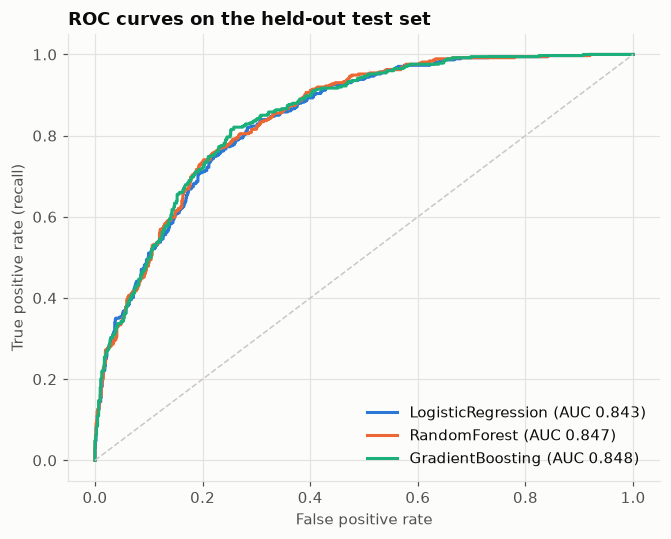

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 5))
for (name, search), color in zip(searches.items(), [BLUE, ORANGE, AQUA]):
    proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC {roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate (recall)")
ax.set_title("ROC curves on the held-out test set")
ax.legend(frameon=False, loc="lower right"); fig.tight_layout(); plt.show()

### Are the differences real? Bootstrap on the test set

In [4]:
rng = np.random.default_rng(42)
test_proba = {n: s.best_estimator_.predict_proba(X_test)[:, 1] for n, s in searches.items()}
y = y_test.to_numpy()
diffs = {f"{best_name} − {other}": [] for other in test_proba if other != best_name}
for _ in range(2000):
    idx = rng.integers(0, len(y), len(y))
    if y[idx].min() == y[idx].max():
        continue
    base = roc_auc_score(y[idx], test_proba[best_name][idx])
    for other in test_proba:
        if other != best_name:
            diffs[f"{best_name} − {other}"].append(base - roc_auc_score(y[idx], test_proba[other][idx]))
pd.DataFrame({k: {"mean_auc_diff": np.mean(v), "ci95_low": np.percentile(v, 2.5),
                  "ci95_high": np.percentile(v, 97.5), "share_positive": np.mean(np.array(v) > 0)}
              for k, v in diffs.items()}).T.round(4)

,mean_auc_diff,ci95_low,ci95_high,share_positive
GradientBoosting − LogisticRegression,0.0050,-0.0004,0.0103,0.964
GradientBoosting − RandomForest,0.0015,-0.0033,0.0062,0.729


**Model choice: Gradient Boosting**, by the agreed rule (highest test ROC-AUC, then recall).
It also has the best recall (80.8%) and F1 of the three, and its CV and test AUC agree
closely (0.848 / 0.848), so it isn't overfitting.

**Caveat:** the three models are **statistically very close**. All test AUCs fall in
0.843–0.848. Against Random Forest the difference is noise (the 95% interval is centred near
0). Against Logistic Regression, Gradient Boosting wins in ~96% of bootstrap resamples, but the
95% interval still just touches 0 and the gain is only ~0.005 AUC. Logistic
regression performs almost as well as the ensembles, which says the churn signal here is largely
simple and additive (contract, tenure, internet type). Gradient Boosting's advantage is small
extra accuracy plus its ability to pick up interactions (e.g. fiber × month-to-month) without
hand-built features. Its tuned configuration is shallow (depth-2 trees), so it's close to an
additive model anyway, which also keeps the Phase 8 SHAP explanations easy to read.

## 2. Feature importance: why these customers churn

This is the central output of the phase. Three views are used, since each answers a
different question:

1. **Grouped permutation importance:** how much ROC-AUC drops when a *whole family* of related
   features is scrambled. This is the most honest measure when features overlap.
2. **Single-feature permutation importance:** the same measure, one column at a time.
3. **Logistic-regression coefficients:** the *direction* of each effect (raises or lowers risk).

Permutation importance is computed on the **held-out test set** with the test-evaluated
Gradient Boosting model, so it reflects what generalises, not what was memorised.

,importance_mean,importance_std
Tenure & lifetime spend,0.0687,0.0031
Contract type,0.0622,0.0072
Protective add-ons,0.0169,0.0030
Internet service type,0.0168,0.0022
Payment & billing,0.0071,0.0017
Monthly price,0.0055,0.0014
Streaming add-ons,0.0027,0.0009
Phone services,0.0012,0.0010
Demographics,0.0006,0.0010
Service breadth,-0.0002,0.0001


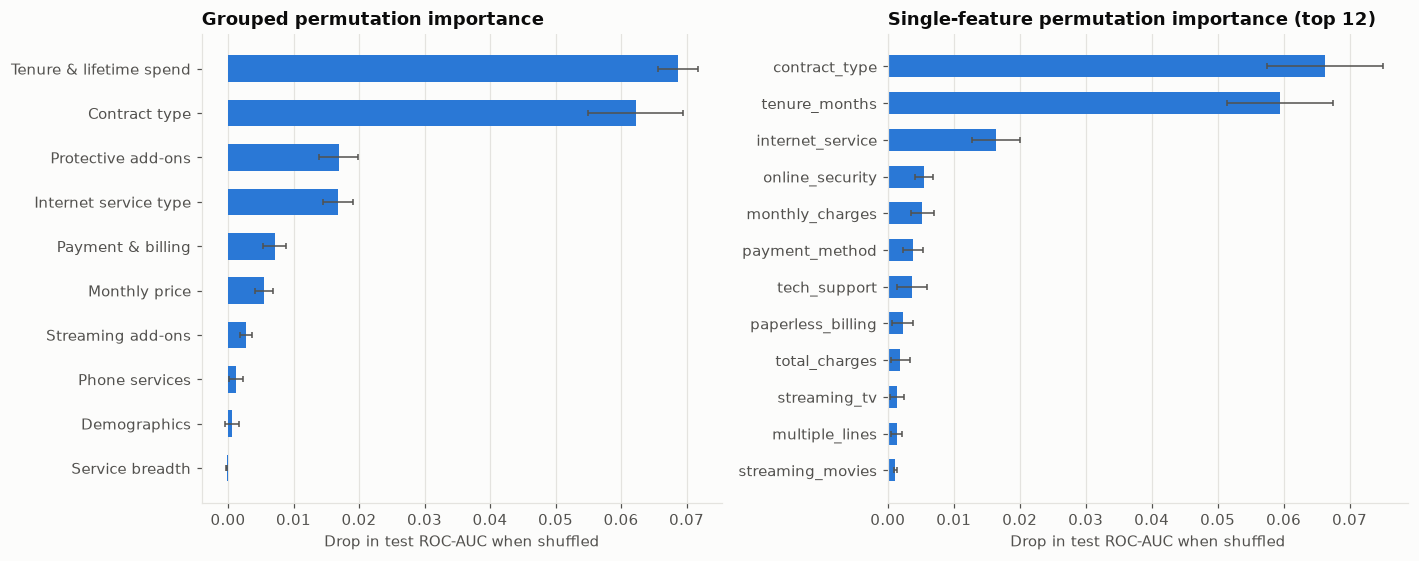

In [5]:
best_test_model = searches[best_name].best_estimator_
grouped = cm.grouped_permutation_importances(best_test_model, X_test, y_test)
single = cm.permutation_importances(best_test_model, X_test, y_test)
display(grouped.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
g = grouped.iloc[::-1]
ax.barh(g.index, g.importance_mean, xerr=g.importance_std, color=BLUE, height=0.6,
        error_kw={"ecolor": INK_2, "elinewidth": 1, "capsize": 2})
ax.set_xlabel("Drop in test ROC-AUC when shuffled"); ax.set_title("Grouped permutation importance")
ax.grid(axis="y", visible=False)

ax = axes[1]
s = single.head(12).iloc[::-1]
ax.barh(s.index, s.importance_mean, xerr=s.importance_std, color=BLUE, height=0.6,
        error_kw={"ecolor": INK_2, "elinewidth": 1, "capsize": 2})
ax.set_xlabel("Drop in test ROC-AUC when shuffled"); ax.set_title("Single-feature permutation importance (top 12)")
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

In [6]:
print("Single-feature permutation importance for the tenure family and RFM scores:")
display(single.loc[["tenure_months", "total_charges", "rfm_recency_score", "rfm_monetary_score",
                    "rfm_frequency_score", "num_services"]].round(4))

Single-feature permutation importance for the tenure family and RFM scores:


,importance_mean,importance_std
tenure_months,0.0594,0.0081
total_charges,0.0019,0.0015
rfm_recency_score,0.0000,0.0000
rfm_monetary_score,0.0000,0.0000
rfm_frequency_score,-0.0002,0.0002
num_services,0.0000,0.0000


### Direction of effects (logistic regression, standardised features)

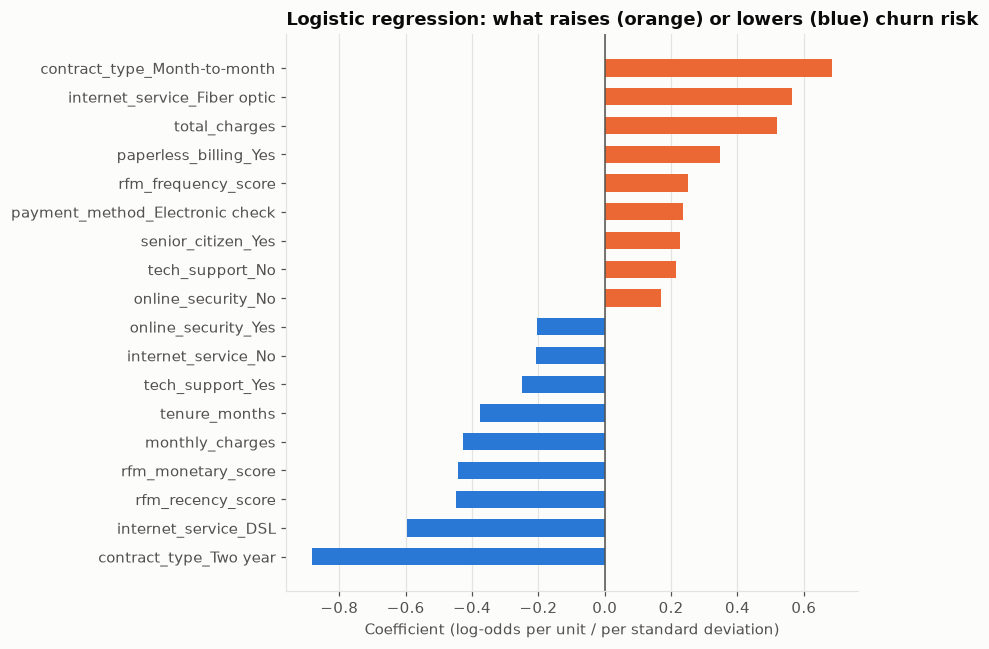

Tuned C = 1.0


In [7]:
lr = searches["LogisticRegression"].best_estimator_
coef = pd.Series(lr.named_steps["model"].coef_[0],
                 index=lr.named_steps["prep"].get_feature_names_out())
coef = coef[~coef.index.str.endswith("No internet service")]   # identical duplicates of internet_service_No
top = pd.concat([coef.nlargest(9), coef.nsmallest(9)]).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=[BLUE if v < 0 else ORANGE for v in top.values], height=0.6)
ax.axvline(0, color=INK_2, linewidth=1)
ax.set_xlabel("Coefficient (log-odds per unit / per standard deviation)")
ax.set_title("Logistic regression: what raises (orange) or lowers (blue) churn risk")
ax.grid(axis="y", visible=False); fig.tight_layout(); plt.show()
print(f"Tuned C = {searches['LogisticRegression'].best_params_['model__C']}")

### Interpretation

**1. Commitment is the strongest single factor: contract type (AUC drop ≈ 0.06).**
Month-to-month is the model's largest built-in split and the largest positive coefficient; a
two-year contract is the largest negative one. A monthly contract costs nothing to exit, so the
customer effectively decides again every month whether to stay. Contracts also *select* for
customers who already intended to stay, so the model captures both a real lock-in effect and a
signal of how committed the customer is.

**2. Tenure matters as much as contract, but its importance is spread across four columns.**
One at a time, `tenure_months` looks strong while `total_charges` and the R/M scores look near
zero. Scrambled *together* ("Tenure & lifetime spend") they're the most important group. The
columns carry the same information, so the model uses whichever is most convenient
(`tenure_months`) and ignores the rest. Business meaning: risk is highest in the first months and
falls with every month survived, matching the EDA (47% first-year churn vs 9.5% after four years).

**3. The RFM scores add no predictive value beyond the raw features.** Their individual
importance is 0. This is an honest finding, not a bug: R and M are quintile-binned versions of
tenure and total charges, and F is a binned service count, so they only repeat information the
model already has, less precisely. RFM remains useful for what it was built for (describing and
communicating segments), but it doesn't help predict churn.

**4. Internet service type (≈ 0.017): fiber optic raises risk.** Fiber has the second-largest
positive coefficient, behind only month-to-month; DSL is strongly negative. Fiber customers pay the most (~$92/month) and
churn at 42%, which points to price-to-value dissatisfaction or strong competitor offers in the
fiber market. This is a product/pricing issue that retention offers alone won't fix.

**5. Protective add-ons (≈ 0.017): the absence of Online Security and Tech Support raises risk.**
`tech_support_No` and `online_security_No` are among the top built-in splits and positive
coefficients. This matches the EDA result that held even within month-to-month customers.
Customers who receive support build trust with the provider and have more reasons to stay. These
add-ons are the most concrete lever in the data: bundling them into offers for at-risk fiber
customers is directly testable.

**6. Payment & billing (≈ 0.007): electronic check and paperless billing raise risk.**
E-check payers must actively pay each month (no auto-pay inertia), and the EDA showed the
effect persists within every contract type. Paperless billing's positive coefficient most
likely reflects digitally engaged customers who find it easier to compare and switch providers,
not billing itself causing churn.

**7. What does *not* matter:** demographics (gender ≈ 0, senior citizen small), phone services,
and service breadth. Once contract, tenure and add-on types are known, *how many* services a
customer has adds nothing. *Which* services they have matters.

**A note on the coefficients.** `total_charges` has a *positive* coefficient while tenure and
the R/M scores are negative, and `monthly_charges` is *negative* even though the EDA showed
churners pay more. That doesn't mean "paying more per month reduces churn". The columns are
collinear (total ≈ monthly × tenure, and monthly price is largely determined by fiber and the
add-ons), so the model splits one effect across them in offsetting ways. Here the price
effect is mostly carried by the fiber coefficient. Individual coefficients on correlated features shouldn't be read in isolation.
That is why the grouped importance above is the primary view.

## 3. Confusion matrix and the cost of errors

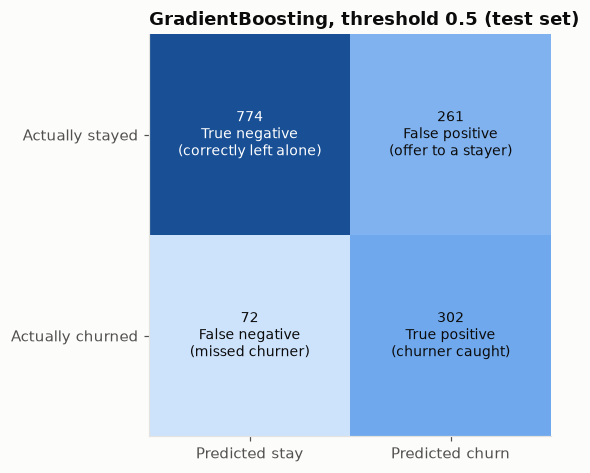

Recall 80.7%: caught 302 of 374 churners, missed 72.
Precision 53.6%: 261 of 563 flagged customers would not have churned.


In [8]:
test_proba_best = test_proba[best_name]
cmatrix = confusion_matrix(y_test, (test_proba_best >= 0.5).astype(int))
tn, fp, fn, tp = cmatrix.ravel()

fig, ax = plt.subplots(figsize=(5.2, 4.4))
from matplotlib.colors import LinearSegmentedColormap
blues = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95"])
ax.imshow(cmatrix, cmap=blues); ax.grid(False)
labels = [["True negative\n(correctly left alone)", "False positive\n(offer to a stayer)"],
          ["False negative\n(missed churner)", "True positive\n(churner caught)"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cmatrix[i, j]:,}\n{labels[i][j]}", ha="center", va="center", fontsize=9,
                color="white" if cmatrix[i, j] > 400 else INK)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted stay", "Predicted churn"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actually stayed", "Actually churned"])
ax.set_title(f"{best_name}, threshold 0.5 (test set)")
fig.tight_layout(); plt.show()
print(f"Recall {tp/(tp+fn):.1%}: caught {tp} of {tp+fn} churners, missed {fn}.")
print(f"Precision {tp/(tp+fp):.1%}: {fp} of {tp+fp} flagged customers would not have churned.")

,tp,fp,fn,tn,precision,recall,flagged_pct
threshold,,,,,,,
0.10,371,705,3,330,0.345,0.992,76.366
0.15,365,624,9,411,0.369,0.976,70.192
0.20,359,562,15,473,0.390,0.960,65.366
0.25,352,510,22,525,0.408,0.941,61.178
0.30,343,445,31,590,0.435,0.917,55.926
0.35,332,394,42,641,0.457,0.888,51.526
0.40,321,345,53,690,0.482,0.858,47.268
0.45,315,312,59,723,0.502,0.842,44.500
0.50,302,261,72,774,0.536,0.807,39.957


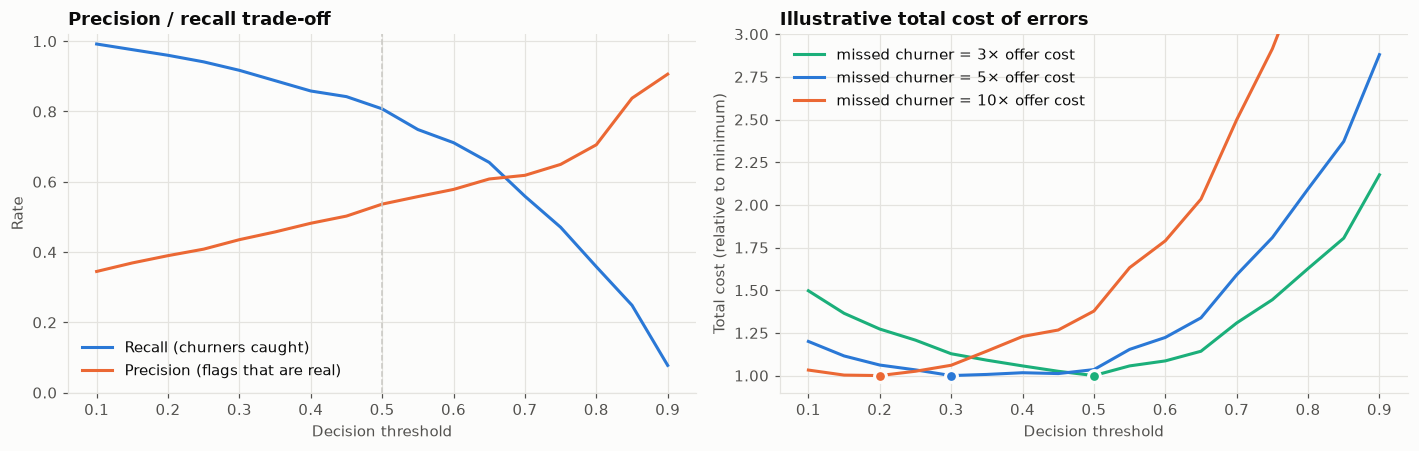

FN:FP cost  3:1 -> lowest-cost threshold 0.50
FN:FP cost  5:1 -> lowest-cost threshold 0.30
FN:FP cost 10:1 -> lowest-cost threshold 0.20


In [9]:
thr = cm.threshold_table(y_test, test_proba_best)
display(thr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(thr.index, thr.recall, color=BLUE, linewidth=2, label="Recall (churners caught)")
ax.plot(thr.index, thr.precision, color=ORANGE, linewidth=2, label="Precision (flags that are real)")
ax.axvline(0.5, color=MUTED, linestyle="--", linewidth=1)
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Rate"); ax.set_ylim(0, 1.02)
ax.set_title("Precision / recall trade-off"); ax.legend(frameon=False, loc="lower left")

# Illustrative only: relative costs, not real dollar figures
ax = axes[1]
for ratio, color in [(3, AQUA), (5, BLUE), (10, ORANGE)]:
    cost = thr.fn * ratio + thr.fp * 1
    ax.plot(thr.index, cost / cost.min(), color=color, linewidth=2, label=f"missed churner = {ratio}× offer cost")
    best_t = cost.idxmin()
    ax.scatter([best_t], [1], color=color, s=60, zorder=3, edgecolor=SURFACE, linewidth=2)
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Total cost (relative to minimum)")
ax.set_ylim(0.9, 3); ax.set_title("Illustrative total cost of errors")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout(); plt.show()

for ratio in (3, 5, 10):
    cost = thr.fn * ratio + thr.fp
    print(f"FN:FP cost {ratio:>2}:1 -> lowest-cost threshold {cost.idxmin():.2f}")

**Business reading.** At the default 0.5 threshold the model catches **~81% of churners**
(302 of 374 in the test set), but about **46% of flagged customers would have stayed**
(261 false positives).

- A **false negative** (missed churner) costs the customer's entire future revenue. With
  churners paying a median of ~$80/month, that is hundreds to thousands of dollars per customer.
- A **false positive** costs only the retention offer given to someone who would have stayed
  (a discount, a free add-on month, an agent's call), usually a small fraction of that.

Because a missed churner is typically several times costlier than a wasted offer, the optimal
threshold is **at or below 0.5**. The right-hand chart uses *illustrative* cost ratios (3:1,
5:1, 10:1, not measured costs) to show that the higher the ratio, the lower the best threshold
and the wider the net. The real ratio depends on the actual offer cost, which the business
needs to supply. The Phase 5 matrix also applies a second filter (customer value), so
low-value false positives won't all receive expensive offers.

**Important for Phase 5: these probabilities are inflated.** Balanced class weighting trains the
model as if churn were a 50/50 event. That improves recall, but the predicted probabilities
run high (see below). They're reliable for **ranking** customers, not as literal percentages.

## 4. Calibration check: predicted vs actual churn

,customers,mean_predicted,actual_rate
decile,,,
1,705,0.039,0.009
2,704,0.068,0.018
3,704,0.117,0.053
4,704,0.202,0.091
5,705,0.314,0.156
6,704,0.443,0.233
7,704,0.571,0.307
8,704,0.687,0.450
9,704,0.787,0.577


Mean predicted probability: 0.411   Actual churn rate: 0.265
Out-of-fold ROC-AUC (all 7,043 customers): 0.8480


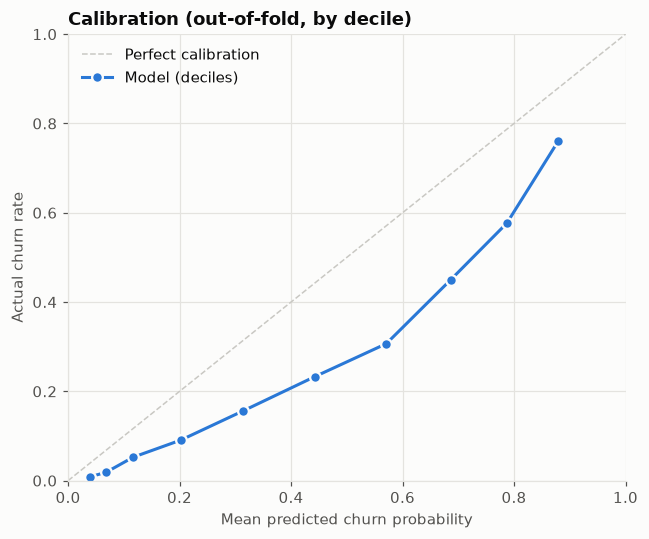

In [10]:
oof = results["oof"]
cal = (pd.DataFrame({"oof": oof, "churn": df["churn"]})
       .assign(decile=lambda d: pd.qcut(d.oof, 10, labels=False) + 1)
       .groupby("decile").agg(customers=("churn", "size"),
                              mean_predicted=("oof", "mean"), actual_rate=("churn", "mean")))
display(cal.round(3))
print(f"Mean predicted probability: {oof.mean():.3f}   Actual churn rate: {df['churn'].mean():.3f}")
print(f"Out-of-fold ROC-AUC (all 7,043 customers): {roc_auc_score(df['churn'], oof):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=1, label="Perfect calibration")
ax.plot(cal.mean_predicted, cal.actual_rate, color=BLUE, linewidth=2, marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="Model (deciles)")
ax.set_xlabel("Mean predicted churn probability"); ax.set_ylabel("Actual churn rate")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_title("Calibration (out-of-fold, by decile)")
ax.legend(frameon=False, loc="upper left"); fig.tight_layout(); plt.show()

**Reading.** The curve sits **below the diagonal**: the model predicts more churn than actually
happens, as expected from balanced class weights. Ranking is still strong (each decile's actual
churn rate rises steadily), so the probabilities order customers correctly.

**Decision needed in Phase 5:** if the retention matrix only uses probabilities to *rank* or
*split* customers (e.g. a median split), no change is needed. If it computes **expected
revenue at risk** (probability × revenue), the probabilities should first be calibrated
(e.g. Platt scaling or isotonic regression on out-of-fold predictions), or that figure will be
overstated.

## 5. Database write-back and saved-model consistency

In [11]:
db = pd.read_sql(text("""
    SELECT customer_id, churn_probability::float AS churn_probability, segment_name
    FROM customer_segments
"""), engine)
print(f"customer_segments rows with churn_probability: {db.churn_probability.notna().sum():,} / {len(db):,}")

merged = df.merge(db, on="customer_id")
final_pred = results["final"].predict_proba(merged[cm.FEATURES])[:, 1]
gap = np.abs(final_pred - merged.churn_probability)
pd.Series({
    "mean |gap|": gap.mean(), "median |gap|": np.median(gap),
    "95th percentile |gap|": np.quantile(gap, 0.95), "max |gap|": gap.max(),
    "correlation": np.corrcoef(final_pred, merged.churn_probability)[0, 1],
    "same side of 0.5": ((final_pred >= 0.5) == (merged.churn_probability >= 0.5)).mean(),
}).round(4)

customer_segments rows with churn_probability: 7,043 / 7,043


mean |gap|               0.0188
median |gap|             0.0122
95th percentile |gap|    0.0565
max |gap|                0.4934
correlation              0.9955
same side of 0.5         0.9769
dtype: float64

In [12]:
outlier = merged.assign(final_model=final_pred, gap=gap).nlargest(3, "gap")
outlier[["customer_id", "churn", "churn_probability", "final_model", "gap",
         "tenure_months", "contract_type", "internet_service", "monthly_charges"]]

,customer_id,churn,churn_probability,final_model,gap,tenure_months,contract_type,internet_service,monthly_charges
2003,2889-FPWRM,1,0.17462,0.668011,0.493391,72,One year,Fiber optic,117.8
714,1051-GEJLJ,0,0.66038,0.436667,0.223713,2,Month-to-month,No,19.5
6389,9053-JZFKV,1,0.13277,0.317664,0.184894,67,Two year,Fiber optic,116.2


**Reading.** The database holds **out-of-fold** probabilities, while the dashboard and SHAP
(Phase 8) use the model refit on all data. For almost every customer the two agree closely (see
the median gap of ~0.01, a correlation of 0.996, and 98% of customers on the same side of 0.5).
For 95% of customers the dashboard number will be within ~6 points of the database value.

The rare large gaps are **rare profiles that went against the usual pattern**. For example, a
72-month, one-year-contract customer paying $118/month for fiber who *churned* anyway (0.17
out-of-fold vs 0.67 from the full model). Each out-of-fold model was trained without 20% of
customers. For a profile with only a handful of similar customers, which ones were left out
changes the prediction a lot, and the full model has also seen this customer's own outcome.
The database value is the fairer estimate because it was produced without seeing the outcome.
The dashboard should label which number it shows.

In [13]:
artifact = cm.load_model()
size_mb = cm.MODEL_PATH.stat().st_size / 1e6
print(f"Saved: models/{cm.MODEL_PATH.name} ({size_mb:.2f} MB)")
print({k: v for k, v in artifact.items() if k not in ("pipeline", "features", "categorical_features", "numeric_features")})
artifact["pipeline"]

Saved: models/churn_model.pkl (0.17 MB)
{'model_name': 'GradientBoosting', 'best_params': {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}, 'test_metrics': {'accuracy': 0.7636621717530163, 'precision': 0.5364120781527532, 'recall': 0.8074866310160428, 'f1': 0.6446104589114194, 'roc_auc': 0.8480301738613759}, 'sklearn_version': '1.9.1', 'trained_at': '2026-09-29T17:20:09+00:00'}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['gender','senior_citizen','partner',...,'rfm_recency_score', 'rfm_frequency_score','rfm_monetary_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It i

The saved artifact is a single scikit-learn `Pipeline` (preprocessing + model) plus metadata.
It takes the **raw** feature columns listed in `artifact["features"]`, so the dashboard's what-if
simulator and `src/explainability.py` can call `pipeline.predict_proba(raw_rows)` directly, and
can access `pipeline.named_steps["prep"]` / `["model"]` separately for SHAP's TreeExplainer.

## Summary

- **Best model:** Gradient Boosting (test ROC-AUC 0.848, recall 81% at threshold 0.5).
  Logistic regression and Random Forest are statistically indistinguishable.
- **What drives churn:** contract commitment and tenure dominate, followed by fiber internet,
  missing Security/Tech Support, and electronic-check payment. Demographics barely matter.
- **RFM scores** add no predictive power beyond the raw features (useful for describing
  segments, not for predicting churn).
- **Threshold:** since missed churners cost more than wasted offers, operate at or below 0.5.
  The exact point depends on real offer costs.
- **Probabilities are ranking-quality, not calibrated.** This needs a decision before Phase 5
  if expected-value calculations are used.